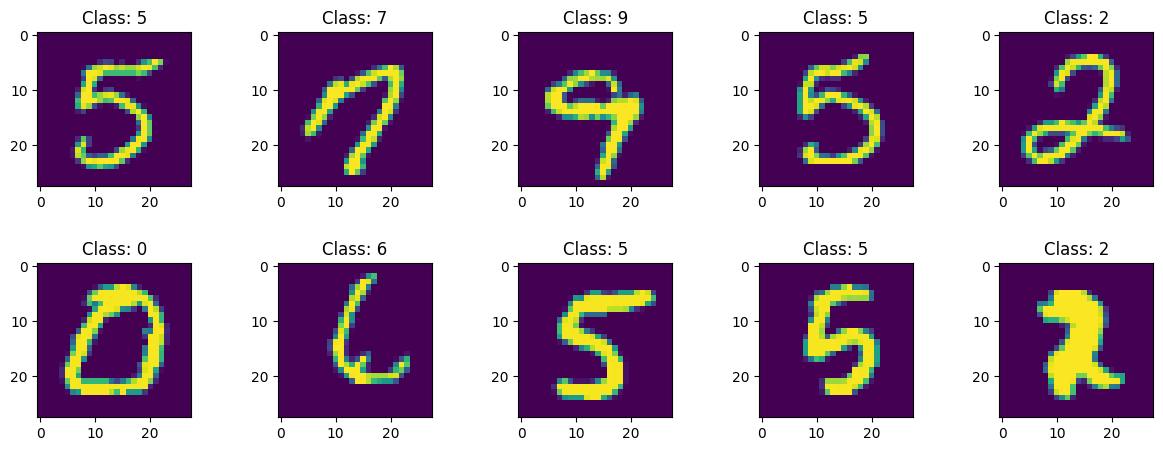

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 16s 91ms/step - accuracy: 0.8249 - loss: 0.6313 - val_accuracy: 0.9310 - val_loss: 0.2450
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 91ms/step - accuracy: 0.9507 - loss: 0.1625 - val_accuracy: 0.9530 - val_loss: 0.1429
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 91ms/step - accuracy: 0.9680 - loss: 0.1082 - val_accuracy: 0.9695 - val_loss: 0.1191
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 90ms/step - accuracy: 0.9741 - loss: 0.0833 - val_accuracy: 0.9680 - val_loss: 0.0952
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - accuracy: 0.9798 - loss: 0.0655 - val_accuracy: 0.9725 - val_loss: 0.0924
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.9822 - loss: 0.0558 - val_accuracy: 0.9730 - val_loss: 0.0869
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.9846 - loss: 0.0489 - val_accuracy: 0.9780 - val_loss: 0.0726
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.9865 - loss: 0.0404 - 

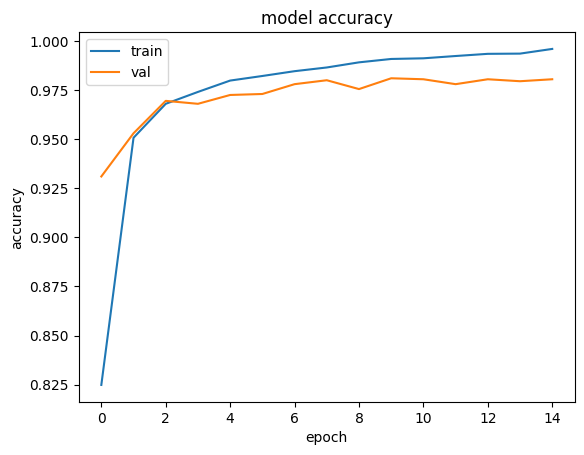

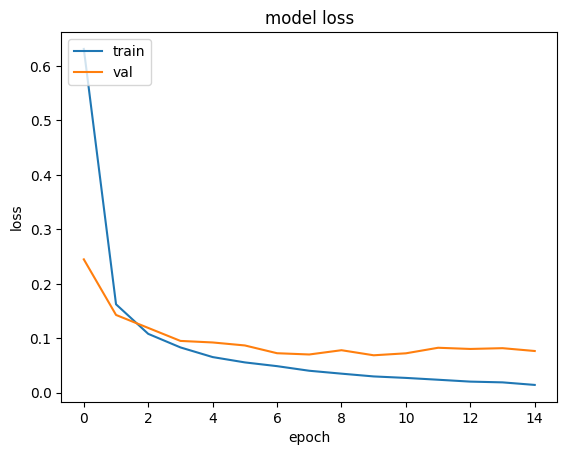

313/313 - 2s - 7ms/step - accuracy: 0.9833 - loss: 0.0563
Test loss: 0.056317269802093506
Test accuracy: 0.9832983016967773


In [2]:
# ==========================================
# 2.1. Nạp thư viện
# ==========================================
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input

# data visualization packages
import matplotlib.pyplot as plt

# ==========================================
# 2.2. Đọc và tiền xử lý dữ liệu MNIST
# ==========================================
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'

df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

# Tách dữ liệu ảnh (X) và nhãn (y)
X_train = df_train.iloc[:, 1:]
y_train = df_train.iloc[:, 0]
X_test = df_test.iloc[:, 1:]
y_test = df_test.iloc[:, 0]

# Định dạng các thông số cấu hình đầu vào
num_classes = 10
input_shape = (28, 28, 1)

# Chuẩn hóa giá trị pixel về đoạn [0, 1]
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255

# Chuyển đổi sang mảng numpy và thay đổi kích thước thành (28, 28, 1)
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1)

X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1)

# ==========================================
# 2.3. Trực quan hóa 10 ảnh đầu tiên (Tùy chọn)
# ==========================================
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 5))
ax = axes.ravel()
for i in range(10):
    ax[i].imshow(X_train[i].reshape(28, 28))
    ax[i].title.set_text("Class: " + str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()

# ==========================================
# 2.4. Chuyển giá trị nhãn thành one-hot encoding
# ==========================================
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# ==========================================
# 2.5. Xây dựng mô hình CNN
# ==========================================
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))

# Hiển thị cấu trúc mạng mạng chập
model.summary()

# ==========================================
# 2.6. Huấn luyện mô hình CNN
# ==========================================
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_fit = model.fit(
    X_train, y_train,
    batch_size=128,
    epochs=15,
    validation_split=0.1,
    verbose=1
)

# ==========================================
# 2.7. Đánh giá mô hình CNN (Vẽ biểu đồ Loss/Accuracy)
# ==========================================
# Biểu đồ Độ chính xác (Accuracy)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# Biểu đồ Hàm mất mát (Loss)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

# ==========================================
# 2.8. Đánh giá mô hình CNN thử nghiệm trên tập test
# ==========================================
score = model.evaluate(X_test, y_test, verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

Kích thước tập huấn luyện: (50000, 32, 32, 3) (50000, 1)
Kích thước tập kiểm thử: (10000, 32, 32, 3) (10000, 1)


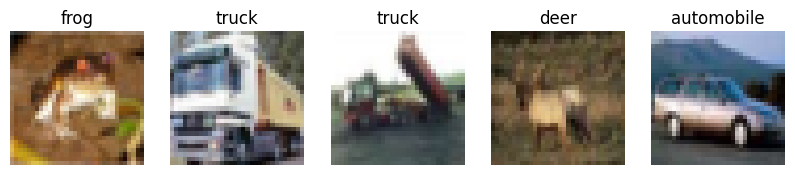

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,250,858 (4.77 MB)

 Trainable params: 1,250,858 (4.77 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 189s 264ms/step - accuracy: 0.4124 - loss: 1.5993 - val_accuracy: 0.5706 - val_loss: 1.2069
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 263ms/step - accuracy: 0.5751 - loss: 1.1999 - val_accuracy: 0.6514 - val_loss: 0.9806
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 185s 262ms/step - accuracy: 0.6438 - loss: 1.0075 - val_accuracy: 0.7082 - val_loss: 0.8228
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 261ms/step - accuracy: 0.6805 - loss: 0.9070 - val_accuracy: 0.7268 - val_loss: 0.7955
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 185s 262ms/step - accuracy: 0.7102 - loss: 0.8227 - val_accuracy: 0.7408 - val_loss: 0.7379
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 261ms/step - accuracy: 0.7329 - loss: 0.7619 - val_accuracy: 0.7686 - val_loss: 0.6727
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 201s 260ms/step - accuracy: 0.7472 - loss: 0.7159 - val_accuracy: 0.7770 - val_loss: 0.6508
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 202s 260ms/step - accuracy: 0.7630 -

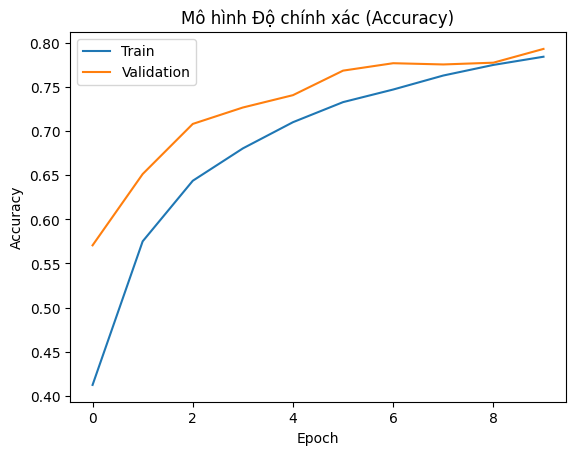

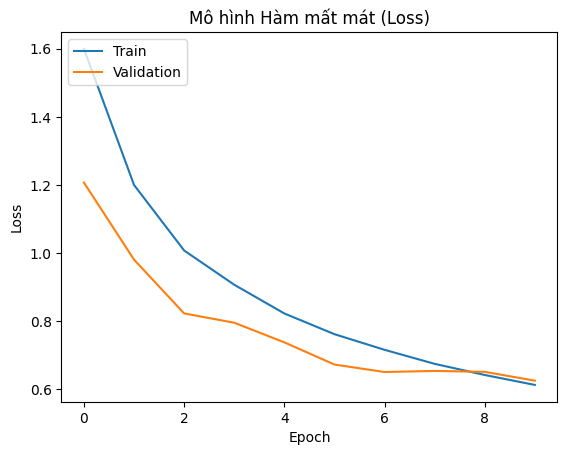

313/313 - 11s - 34ms/step - accuracy: 0.7779 - loss: 0.6498

Kết quả trên tập Test độc lập:
Test loss: 0.6497942209243774
Test accuracy: 0.777899980545044


Saving test.jpg to test.jpg
Đang xử lý ảnh: "test.jpg"


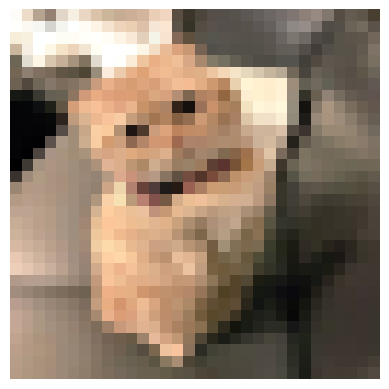

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
👉 Kết quả dự đoán: DOG (Độ tự tin: 95.13%)


In [5]:
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Dropout
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt

# ==========================================
# 1. Tải và nạp dữ liệu CIFAR-10 từ thư viện tensorflow
# ==========================================
cifar10 = keras.datasets.cifar10
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Kích thước tập huấn luyện:", X_train.shape, y_train.shape)
print("Kích thước tập kiểm thử:", X_test.shape, y_test.shape)

# Tên các nhãn đối tượng trong bộ dữ liệu CIFAR-10
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# ==========================================
# 2. Tiền xử lý dữ liệu
# ==========================================
num_classes = 10
input_shape = (32, 32, 3) # Ảnh màu kích thước 32x32 với 3 kênh màu (RGB)

# Chuẩn hóa giá trị pixel từ đoạn [0, 255] về đoạn [0, 1]
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Chuyển đổi nhãn phân lớp sang định dạng One-hot Encoding
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# ==========================================
# 3. Trực quan hóa một vài ảnh mẫu (Tùy chọn)
# ==========================================
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[i])
    # Lấy ra tên nhãn thực tế dựa trên vị trí One-hot mang giá trị 1
    label_idx = np.argmax(y_train[i])
    plt.title(class_names[label_idx])
    plt.axis('off')
plt.show()

# ==========================================
# 4. Xây dựng mô hình mạng chập CNN
# ==========================================
model = Sequential()
model.add(Input(shape=input_shape))

# Khối chập 1
model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25)) # Giúp hạn chế hiện tượng quá khớp (Overfitting)

# Khối chập 2
model.add(Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# Khối phân lớp (Fully Connected Layer)
model.add(Flatten())
model.add(Dense(units=512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=num_classes, activation='softmax')) # Tầng đầu ra với 10 lớp

# Hiển thị tóm tắt thông số cấu trúc mạng mạng chập
model.summary()

# ==========================================
# 5. Biên dịch và Huấn luyện mô hình
# ==========================================
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model_fit = model.fit(
    X_train, y_train,
    batch_size=64,       # Kích thước lô dữ liệu xử lý
    epochs=15,           # Số chu kỳ huấn luyện
    validation_split=0.1, # Trích 10% tập train làm tập validation đánh giá
    verbose=1
)

# ==========================================
# 6. Vẽ đồ thị đánh giá (Loss / Accuracy)
# ==========================================
# Biểu đồ độ chính xác
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Mô hình Độ chính xác (Accuracy)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Biểu đồ hàm mất mát
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Mô hình Hàm mất mát (Loss)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# ==========================================
# 7. Đánh giá kiểm thử mô hình trên tập Test độc lập
# ==========================================
score = model.evaluate(X_test, y_test, verbose=2)
print('\nKết quả trên tập Test độc lập:')
print('Test loss:', score[0])
print('Test accuracy:', score[1])

# ==========================================
# 8. Tải ảnh từ máy tính lên và dự đoán nhãn (Dành cho Google Colab)
# ==========================================
from google.colab import files
from keras.preprocessing import image
from PIL import Image

# Tạo nút bấm để chọn ảnh từ máy tính của bạn
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'Đang xử lý ảnh: "{filename}"')

    # 1. Đọc ảnh và chuyển kích thước về đúng chuẩn 32x32 của CIFAR-10
    img = Image.open(filename)
    img_resized = img.resize((32, 32))

    # Trực quan hóa ảnh bạn vừa tải lên
    plt.imshow(img_resized)
    plt.axis('off')
    plt.show()

    # 2. Chuyển ảnh thành mảng numpy và tiền xử lý
    img_array = np.array(img_resized)

    # Nếu ảnh có kênh suốt (Alpha) - 4 kênh, thì chỉ lấy 3 kênh RGB
    if img_array.shape[-1] == 4:
        img_array = img_array[:, :, :3]

    # Chuẩn hóa giá trị pixel về đoạn [0, 1] giống như lúc train
    img_array = img_array.astype('float32') / 255.0

    # Thêm một chiều (Dimension) vào đầu để tạo thành batch_size = 1 -> (1, 32, 32, 3)
    img_processed = np.expand_dims(img_array, axis=0)

    # 3. Đưa vào mô hình để dự đoán
    predictions = model.predict(img_processed)

    # Lấy ra chỉ số của lớp có xác suất cao nhất
    predicted_class_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class_idx] * 100

    # In kết quả dự đoán ra màn hình
    predicted_label = class_names[predicted_class_idx]
    print(f"👉 Kết quả dự đoán: {predicted_label.upper()} (Độ tự tin: {confidence:.2f}%)")

Các lớp đối tượng nhận diện: ['cat', 'dog']


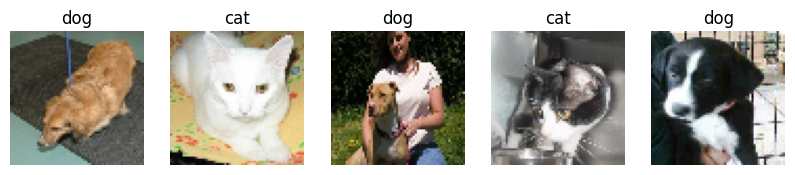

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_28 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 156s 260ms/step - accuracy: 0.6383 - loss: 0.6271 - val_accuracy: 0.7410 - val_loss: 0.5226
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 160s 273ms/step - accuracy: 0.7562 - loss: 0.5037 - val_accuracy: 0.7936 - val_loss: 0.4439
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 160s 273ms/step - accuracy: 0.7988 - loss: 0.4360 - val_accuracy: 0.7986 - val_loss: 0.4316
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 151s 258ms/step - accuracy: 0.8364 - loss: 0.3714 - val_accuracy: 0.8272 - val_loss: 0.3825
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 210s 270ms/step - accuracy: 0.8605 - loss: 0.3243 - val_accuracy: 0.8356 - val_loss: 0.3754
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 195s 257ms/step - accuracy: 0.8861 - loss: 0.2723 - val_accuracy: 0.8216 - val_loss: 0.4248
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 202s 257ms/step - accuracy: 0.9041 - loss: 0.2330 - val_accuracy: 0.8353 - val_loss: 0.3922
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 160s 273ms/step - accuracy: 0.9185 -

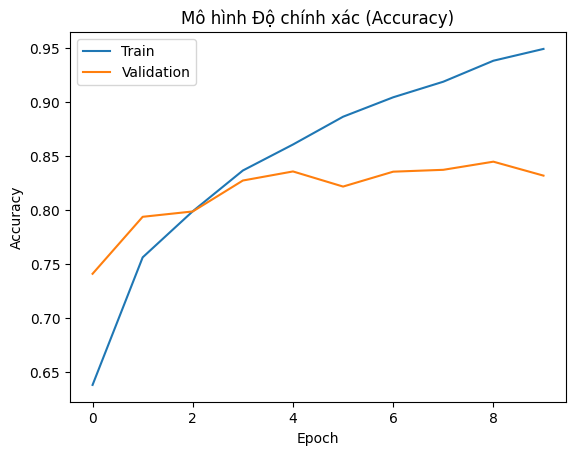

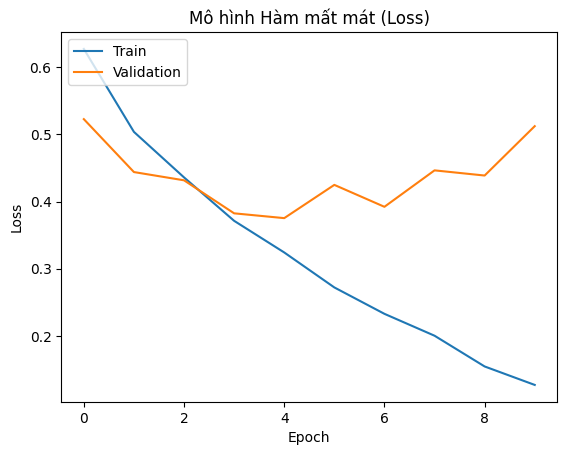

146/146 - 13s - 88ms/step - accuracy: 0.8317 - loss: 0.5122

Kết quả trên tập Test của Cats vs Dogs:
Test loss: 0.5121902227401733
Test accuracy: 0.8316853046417236

👇 BẤM VÀO NÚT DƯỚI ĐÂY ĐỂ TẢI ẢNH LÊN:


FileUpload(value={}, accept='image/*', description='Upload')

Output()

In [ ]:
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Dropout
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt
# Sử dụng thư viện tensorflow_datasets để tải dữ liệu trực tuyến
import tensorflow_datasets as tfds
# Các thư viện bổ sung cho chức năng upload và xử lý ảnh liên tục
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
import io

# ==========================================
# 1. Tải trực tiếp dữ liệu Cats vs Dogs từ Tensorflow
# ==========================================
# Trích xuất 80% cho tập Train và 20% cho tập Test
(train_ds, test_ds), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    with_info=True,
    as_supervised=True,  # Trả về cặp dữ liệu dạng (image, label)
)

# Tên các nhãn phân lớp phân loại: ['cat', 'dog']
class_names = ds_info.features['label'].names
print("Các lớp đối tượng nhận diện:", class_names)

# ==========================================
# 2. Tiền xử lý dữ liệu (Resize & Normalize)
# ==========================================
IMG_SIZE = 64 # Đồng bộ tất cả ảnh về kích thước cố định 64x64
num_classes = 1
input_shape = (IMG_SIZE, IMG_SIZE, 3)

def preprocess_image(image, label):
    # Đưa kích thước ảnh về chuẩn cố định
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    # Chuẩn hóa giá trị các pixel từ [0, 255] về đoạn [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Áp dụng hàm tiền xử lý lên toàn bộ tập dữ liệu bằng cơ chế Map
BATCH_SIZE = 32
train_dataset = train_ds.map(preprocess_image).shuffle(1000).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
test_dataset = test_ds.map(preprocess_image).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

# ==========================================
# 3. Trực quan hóa một vài ảnh mẫu
# ==========================================
plt.figure(figsize=(10, 2))
for images, labels in train_dataset.take(1):
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(images[i].numpy())
        label_idx = labels[i].numpy()
        plt.title(class_names[label_idx])
        plt.axis('off')
plt.show()

# ==========================================
# 4. Xây dựng cấu trúc mô hình mạng chập CNN
# ==========================================
model = Sequential()
model.add(Input(shape=input_shape))

# Khối chập 1
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

# Khối chập 2
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

# Khối chập 3
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

# Khối phân lớp phẳng (Fully Connected)
model.add(Flatten())
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.5)) # Tránh quá khớp (overfitting) do ảnh thực tế rất đa dạng
# Hàm kích hoạt Sigmoid xuất ra xác suất nhị phân (0: Cat, 1: Dog)
model.add(Dense(units=1, activation='sigmoid'))

# Hiển thị tóm tắt thông số cấu trúc mạng
model.summary()

# ==========================================
# 5. Biên dịch và Huấn luyện mô hình CNN
# ==========================================
# Sử dụng loss='binary_crossentropy' chuyên biệt cho bài toán phân loại 2 lớp
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

epochs = 10
model_fit = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=epochs,
    verbose=1
)

# ==========================================
# 6. Vẽ đồ thị đánh giá (Loss / Accuracy)
# ==========================================
# Biểu đồ độ chính xác (Accuracy)
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('Mô hình Độ chính xác (Accuracy)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Biểu đồ hàm mất mát (Loss)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Mô hình Hàm mất mát (Loss)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# ==========================================
# 7. Đánh giá thử nghiệm trên tập kiểm thử độc lập
# ==========================================
score = model.evaluate(test_dataset, verbose=2)
print('\nKết quả trên tập Test của Cats vs Dogs:')
print('Test loss:', score[0])
print('Test accuracy:', score[1])


# ==========================================
# 8. Giao diện Upload và Nhận diện ảnh liên tục
# ==========================================
# Tạo nút bấm Upload tệp (chỉ nhận file ảnh và nhận 1 file mỗi lần chọn)
uploader = widgets.FileUpload(
    accept='image/*',
    multiple=False
)

# Tạo vùng hiển thị kết quả đầu ra
output_zone = widgets.Output()

def on_image_upload(change):
    with output_zone:
        # Xóa kết quả nhận diện cũ trước khi in kết quả mới
        clear_output(wait=True)

        # Kiểm tra xem có dữ liệu ảnh được upload chưa
        if not uploader.value:
            return

        print("🔄 Đang xử lý và nhận diện ảnh mới...")

        # Đọc dữ liệu nhị phân từ tệp ảnh vừa tải lên
        uploaded_file = uploader.value[0]
        image_content = uploaded_file['content']

        # 1. Đọc và ép kích thước ảnh về chuẩn IMG_SIZE (64x64) giống tập Train
        img = Image.open(io.BytesIO(image_content))
        img_resized = img.resize((IMG_SIZE, IMG_SIZE))

        # Hiển thị ảnh vừa upload ra màn hình để kiểm tra
        plt.figure(figsize=(3, 3))
        plt.imshow(img_resized)
        plt.axis('off')
        plt.show()

        # 2. Tiền xử lý định dạng ảnh trước khi đưa vào mô hình
        img_array = np.array(img_resized)
        if img_array.shape[-1] == 4: # Loại bỏ kênh alpha (trong suốt) nếu có
            img_array = img_array[:, :, :3]

        # Chuẩn hóa pixel về đoạn [0, 1] giống hàm preprocess_image
        img_array = img_array.astype('float32') / 255.0
        # Thêm chiều batch thành (1, 64, 64, 3) để tương thích đầu vào
        img_processed = np.expand_dims(img_array, axis=0)

        # 3. Dự đoán kết quả từ mô hình CNN đã huấn luyện
        prediction = model.predict(img_processed, verbose=0)[0][0]

        # Áp dụng ngưỡng phân loại nhị phân (0.5 cho Sigmoid)
        if prediction > 0.5:
            label = "DOG (CHÓ)"
            confidence = prediction * 100
        else:
            label = "CAT (MÈO)"
            confidence = (1 - prediction) * 100

        print(f"👉 KẾT QUẢ DỰ ĐOÁN: {label}")
        print(f"📊 Độ tự tin (Confidence): {confidence:.2f}%")
        print("\n💡 Bạn có thể bấm vào nút 'Upload' lần nữa để kiểm tra hình ảnh khác.")

# Lắng nghe sự kiện thay đổi giá trị để kích hoạt hàm nhận diện
uploader.observe(on_image_upload, names='value')

# Hiển thị các widget ra màn hình
print("\n" + "="*40)
print("👇 BẤM VÀO NÚT DƯỚI ĐÂY ĐỂ TẢI ẢNH LÊN:")
display(uploader)
display(output_zone)

Các lớp đối tượng nhận diện: ['cat', 'dog']


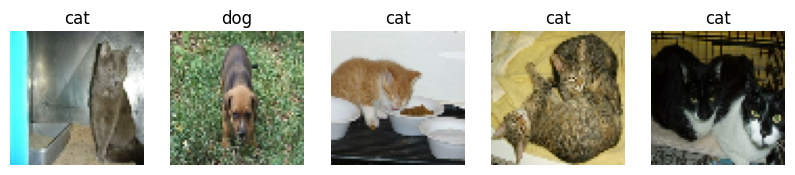

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 683,329 (2.61 MB)

 Trainable params: 683,329 (2.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 154s 259ms/step - accuracy: 0.6424 - loss: 0.6182 - val_accuracy: 0.7337 - val_loss: 0.5255
Epoch 2/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 149s 255ms/step - accuracy: 0.7611 - loss: 0.4936 - val_accuracy: 0.7951 - val_loss: 0.4438
Epoch 3/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 150s 255ms/step - accuracy: 0.8073 - loss: 0.4214 - val_accuracy: 0.8063 - val_loss: 0.4141
Epoch 4/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 203s 257ms/step - accuracy: 0.8390 - loss: 0.3655 - val_accuracy: 0.8218 - val_loss: 0.3901
Epoch 5/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 159s 269ms/step - accuracy: 0.8605 - loss: 0.3204 - val_accuracy: 0.8345 - val_loss: 0.3865
Epoch 6/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 150s 256ms/step - accuracy: 0.8796 - loss: 0.2848 - val_accuracy: 0.8364 - val_loss: 0.3733
Epoch 7/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 151s 258ms/step - accuracy: 0.8946 - loss: 0.2448 - val_accuracy: 0.8422 - val_loss: 0.3763
Epoch 8/10
582/582 ━━━━━━━━━━━━━━━━━━━━ 150s 256ms/step - accuracy: 0.9140 -

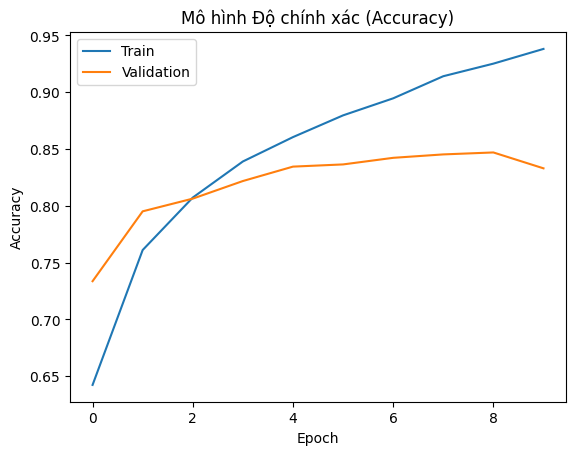

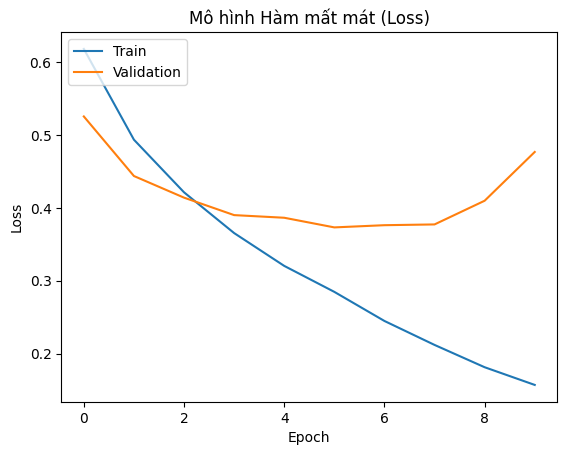

146/146 - 13s - 87ms/step - accuracy: 0.8330 - loss: 0.4768

Kết quả trên tập Test của Cats vs Dogs:
Test loss: 0.4768068492412567
Test accuracy: 0.8329750895500183

👇 HÃY CLICK NÚT DƯỚI ĐÂY ĐỂ TRẢI NGHIỆM NHẬN DIỆN:


FileUpload(value={}, accept='image/*', description='Upload')

Output()

In [11]:
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten, Dropout
from keras.models import Sequential
from keras import Input
import matplotlib.pyplot as plt
# Sử dụng thư viện tensorflow_datasets để tải dữ liệu trực tuyến
import tensorflow_datasets as tfds
# Thư viện hỗ trợ tạo nút bấm upload tương tác liên tục
import ipywidgets as widgets
from IPython.display import display, clear_output
from PIL import Image
import io

# ==========================================
# 1. Tải trực tiếp dữ liệu Cats vs Dogs từ Tensorflow
# ==========================================
# Trích xuất 80% cho tập Train và 20% cho tập Test
(train_ds, test_ds), ds_info = tfds.load(
    'cats_vs_dogs',
    split=['train[:80%]', 'train[80%:]'],
    with_info=True,
    as_supervised=True,  # Trả về cặp dữ liệu dạng (image, label)
)

# Tên các nhãn phân lớp phân loại: ['cat', 'dog']
class_names = ds_info.features['label'].names
print("Các lớp đối tượng nhận diện:", class_names)

# ==========================================
# 2. Tiền xử lý dữ liệu (Resize & Normalize)
# ==========================================
IMG_SIZE = 64 # Đồng bộ tất cả ảnh về kích thước cố định 64x64
num_classes = 1
input_shape = (IMG_SIZE, IMG_SIZE, 3)

def preprocess_image(image, label):
    # Đưa kích thước ảnh về chuẩn cố định
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    # Chuẩn hóa giá trị các pixel từ [0, 255] về đoạn [0, 1]
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

# Áp dụng hàm tiền xử lý lên toàn bộ tập dữ liệu bằng cơ chế Map
BATCH_SIZE = 32
train_dataset = train_ds.map(preprocess_image).shuffle(1000).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)
test_dataset = test_ds.map(preprocess_image).batch(BATCH_SIZE).prefetch(buffer_size=tf.data.AUTOTUNE)

# ==========================================
# 3. Trực quan hóa một vài ảnh mẫu
# ==========================================
plt.figure(figsize=(10, 2))
for images, labels in train_dataset.take(1):
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.imshow(images[i].numpy())
        label_idx = labels[i].numpy()
        plt.title(class_names[label_idx])
        plt.axis('off')
plt.show()

# ==========================================
# 4. Xây dựng cấu trúc mô hình mạng chập CNN
# ==========================================
model = Sequential()
model.add(Input(shape=input_shape))

# Khối chập 1
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

# Khối chập 2
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

# Khối chập 3
model.add(Conv2D(128, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

# Khối phân lớp phẳng (Fully Connected)
model.add(Flatten())
model.add(Dense(units=128, activation='relu'))
model.add(Dropout(0.5)) # Tránh quá khớp (overfitting) do ảnh thực tế rất đa dạng
# Hàm kích hoạt Sigmoid xuất ra xác suất nhị phân (0: Cat, 1: Dog)
model.add(Dense(units=1, activation='sigmoid'))

# Hiển thị tóm tắt thông số cấu trúc mạng
model.summary()

# ==========================================
# 5. Biên dịch và Huấn luyện mô hình CNN
# ==========================================
# Sử dụng loss='binary_crossentropy' chuyên biệt cho bài toán phân loại 2 lớp
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

epochs = 10
model_fit = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=epochs,
    verbose=1
)
# ==========================================
# 6. Vẽ đồ thị đánh giá (Loss / Accuracy)
# ==========================================
# Biểu đồ độ chính xác (Sửa lỗi KeyError ở đây)
try:
    plt.plot(model_fit.history['accuracy'])
    plt.plot(model_fit.history['val_accuracy'])
except KeyError:
    # Nếu hệ thống của bạn dùng phiên bản cũ, nó sẽ tự động chạy dòng dưới đây
    plt.plot(model_fit.history['acc'])
    plt.plot(model_fit.history['val_acc'])

plt.title('Mô hình Độ chính xác (Accuracy)')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Biểu đồ hàm mất mát (Giữ nguyên)
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('Mô hình Hàm mất mát (Loss)')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


# ==========================================
# 7. Đánh giá thử nghiệm trên tập kiểm thử độc lập
# ==========================================
score = model.evaluate(test_dataset, verbose=2)
print('\nKết quả trên tập Test của Cats vs Dogs:')
print('Test loss:', score[0])
print('Test accuracy:', score[1])


# ==========================================
# 8. Giao diện Tương tác Upload và Nhận diện ảnh liên tục
# ==========================================
# Khởi tạo widget uploader (chỉ nhận định dạng ảnh)
uploader = widgets.FileUpload(
    accept='image/*',
    multiple=False
)

# Tạo khu vực hiển thị log kết quả độc lập
output_zone = widgets.Output()

def on_image_upload(change):
    with output_zone:
        # Xóa sạch hình ảnh và kết quả dự đoán của lượt trước
        clear_output(wait=True)

        if not uploader.value:
            return

        print("🔄 Đang xử lý dữ liệu và nhận diện...")

        # Đọc luồng byte dữ liệu từ ảnh được đẩy lên
        uploaded_file = uploader.value[0]
        image_content = uploaded_file['content']

        # Đọc ảnh gốc bằng PIL và nén về kích thước chuẩn 64x64
        img = Image.open(io.BytesIO(image_content))
        img_resized = img.resize((IMG_SIZE, IMG_SIZE))

        # Vẽ ảnh lên màn hình giao diện
        plt.figure(figsize=(3, 3))
        plt.imshow(img_resized)
        plt.axis('off')
        plt.show()

        # Tiền xử lý dữ liệu ảnh thành dạng mảng Numpy
        img_array = np.array(img_resized)
        if img_array.shape[-1] == 4: # Bỏ kênh trong suốt Alpha (nếu là ảnh .png)
            img_array = img_array[:, :, :3]

        # Chia tỉ lệ pixel về khoảng [0, 1] và tăng chiều mảng (Batch size = 1)
        img_array = img_array.astype('float32') / 255.0
        img_processed = np.expand_dims(img_array, axis=0)

        # Gọi mô hình dự đoán xác suất nhị phân
        prediction = model.predict(img_processed, verbose=0)[0][0]

        # Với hàm kích hoạt đầu ra Sigmoid: thiên về 1 là DOG, ngược lại thiên về 0 là CAT
        if prediction > 0.5:
            label = "DOG (CHÓ)"
            confidence = prediction * 100
        else:
            label = "CAT (MÈO)"
            confidence = (1 - prediction) * 100

        print(f"👉 KẾT QUẢ DỰ ĐOÁN: {label}")
        print(f"📊 Độ tin cậy (Confidence): {confidence:.2f}%")
        print("\n💡 Gợi ý: Bạn có thể click lại vào nút 'Upload' để thay ảnh khác ngay lập tức.")

# Thiết lập bộ lắng nghe sự kiện thay đổi dữ liệu đầu vào của nút bấm
uploader.observe(on_image_upload, names='value')

# Hiển thị nút bấm ra màn hình
print("\n" + "="*45)
print("👇 HÃY CLICK NÚT DƯỚI ĐÂY ĐỂ TRẢI NGHIỆM NHẬN DIỆN:")
display(uploader)
display(output_zone)